## Wholesale customers Using Unsupervised Machine Learning

Project Goal

Wholesale customers into distinct groups based on their spending behavior and demographics using clustering algorithms. The insights can help businesses design targeted marketing strategies and personalize customer engagement.

Dataset 

Dataset The dataset used in this project was obtained from Kaggle. Original Dataset:
https://archive.ics.uci.edu/dataset/292/wholesale+customers?utm_source=chatgpt.com

 Thanks to the dataset author for making this data publicly available.

Content

Dataset Information

Rows: 440
Columns: 8

Feature	                    Description
Channel           	Customer type (Hotel/Restaurant/Cafe or Retail)
Region            	Geographic region
Fresh	            Annual spending on fresh products
Milk	            Annual spending on milk products
Grocery	            Annual spending on grocery products
Frozen          	Annual spending on frozen products
Detergents_Paper	Annual spending on detergents and paper products
Delicassen	        Annual spending on delicatessen products

This is an unsupervised learning dataset because there is no target variable. The goal is to discover customer groups using clustering.

## Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage


import warnings
warnings.filterwarnings("ignore")

## Create Output Folders Automatically

In [2]:
from pathlib import Path

project_dir = Path.cwd()

for folder in ["images", "results", "models", "reports"]:
    (project_dir / folder).mkdir(exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


## Load Dataset

In [3]:
df = pd.read_csv('/kaggle/input/datasets/ghadaelfeki/wholesale-customers1-ml-project-gh/Wholesale customers data.csv')

## Explore Dataset

In [4]:
print(df.head())

print()

print(df.info())

print()

print(df.describe())

print()

print(df.shape)

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen 

## Column Names

In [5]:
print(df.columns)

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')


## Check Missing Values

In [6]:
print(df.isnull().sum())

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


## Remove Duplicates

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicate Rows: 0


## Data Types

In [8]:
print(df.dtypes)

Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object


## Save Dataset Summary

In [9]:
summary = df.describe()

print(summary)

summary.to_csv(
    project_dir / "results" / "descriptive_statistics.csv",
    index=False
)

          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.328865   7380.377175   9503.162829   
min      1.000000    1.000000       3.000000     55.000000      3.000000   
25%      1.000000    2.000000    3127.750000   1533.000000   2153.000000   
50%      1.000000    3.000000    8504.000000   3627.000000   4755.500000   
75%      2.000000    3.000000   16933.750000   7190.250000  10655.750000   
max      2.000000    3.000000  112151.000000  73498.000000  92780.000000   

             Frozen  Detergents_Paper    Delicassen  
count    440.000000        440.000000    440.000000  
mean    3071.931818       2881.493182   1524.870455  
std     4854.673333       4767.854448   2820.105937  
min       25.000000          3.000000      3.000000  
25%      742.250000        256.750000    408.

## Exploratory Data Analysis (EDA)

Histograms

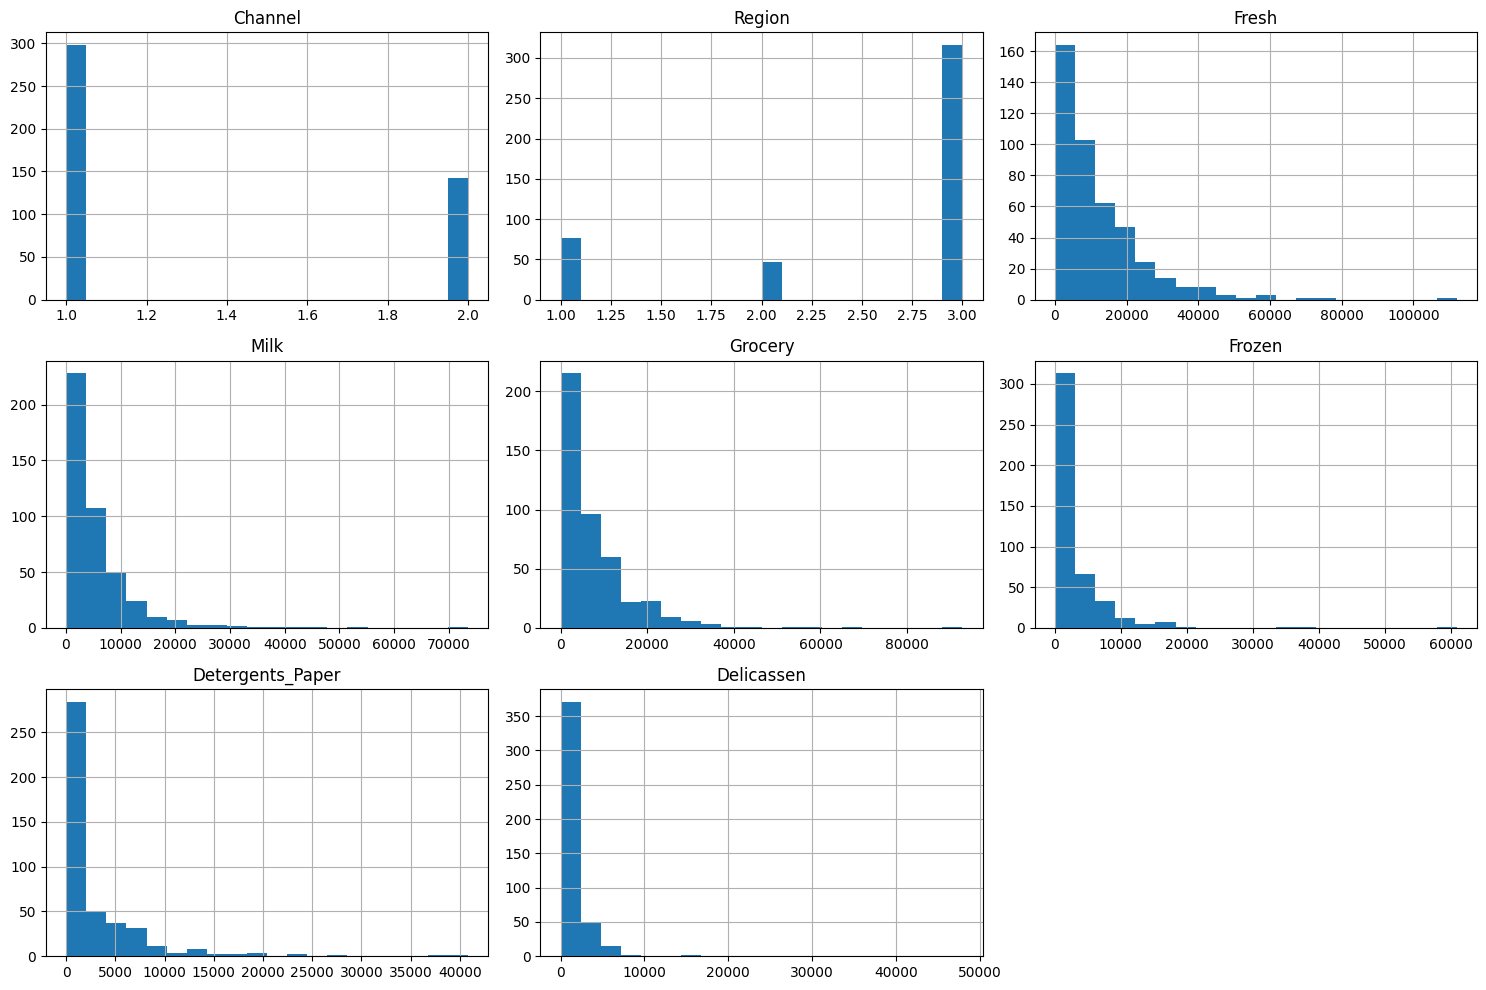

In [10]:
df.hist(

    figsize=(15,10),

    bins=20

)

plt.tight_layout()

plt.savefig(
    project_dir / "images" / "histograms.png",
    dpi=300

)

plt.show()

## Correlation Heatmap

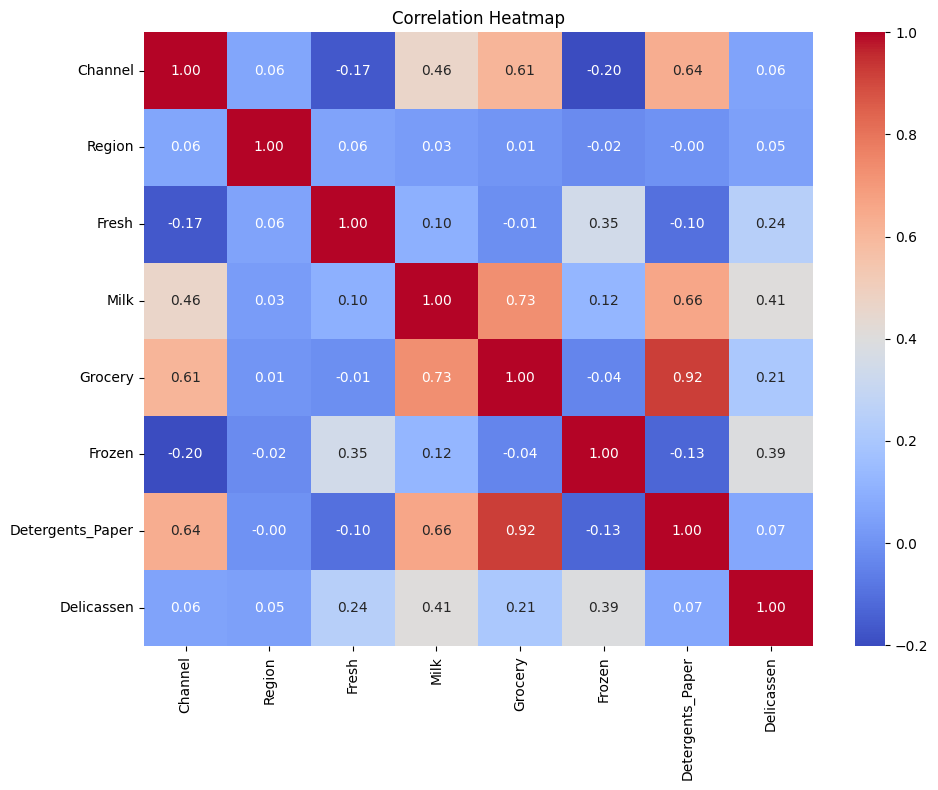

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(

    df.corr(),

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    project_dir / "images" / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Pairplot

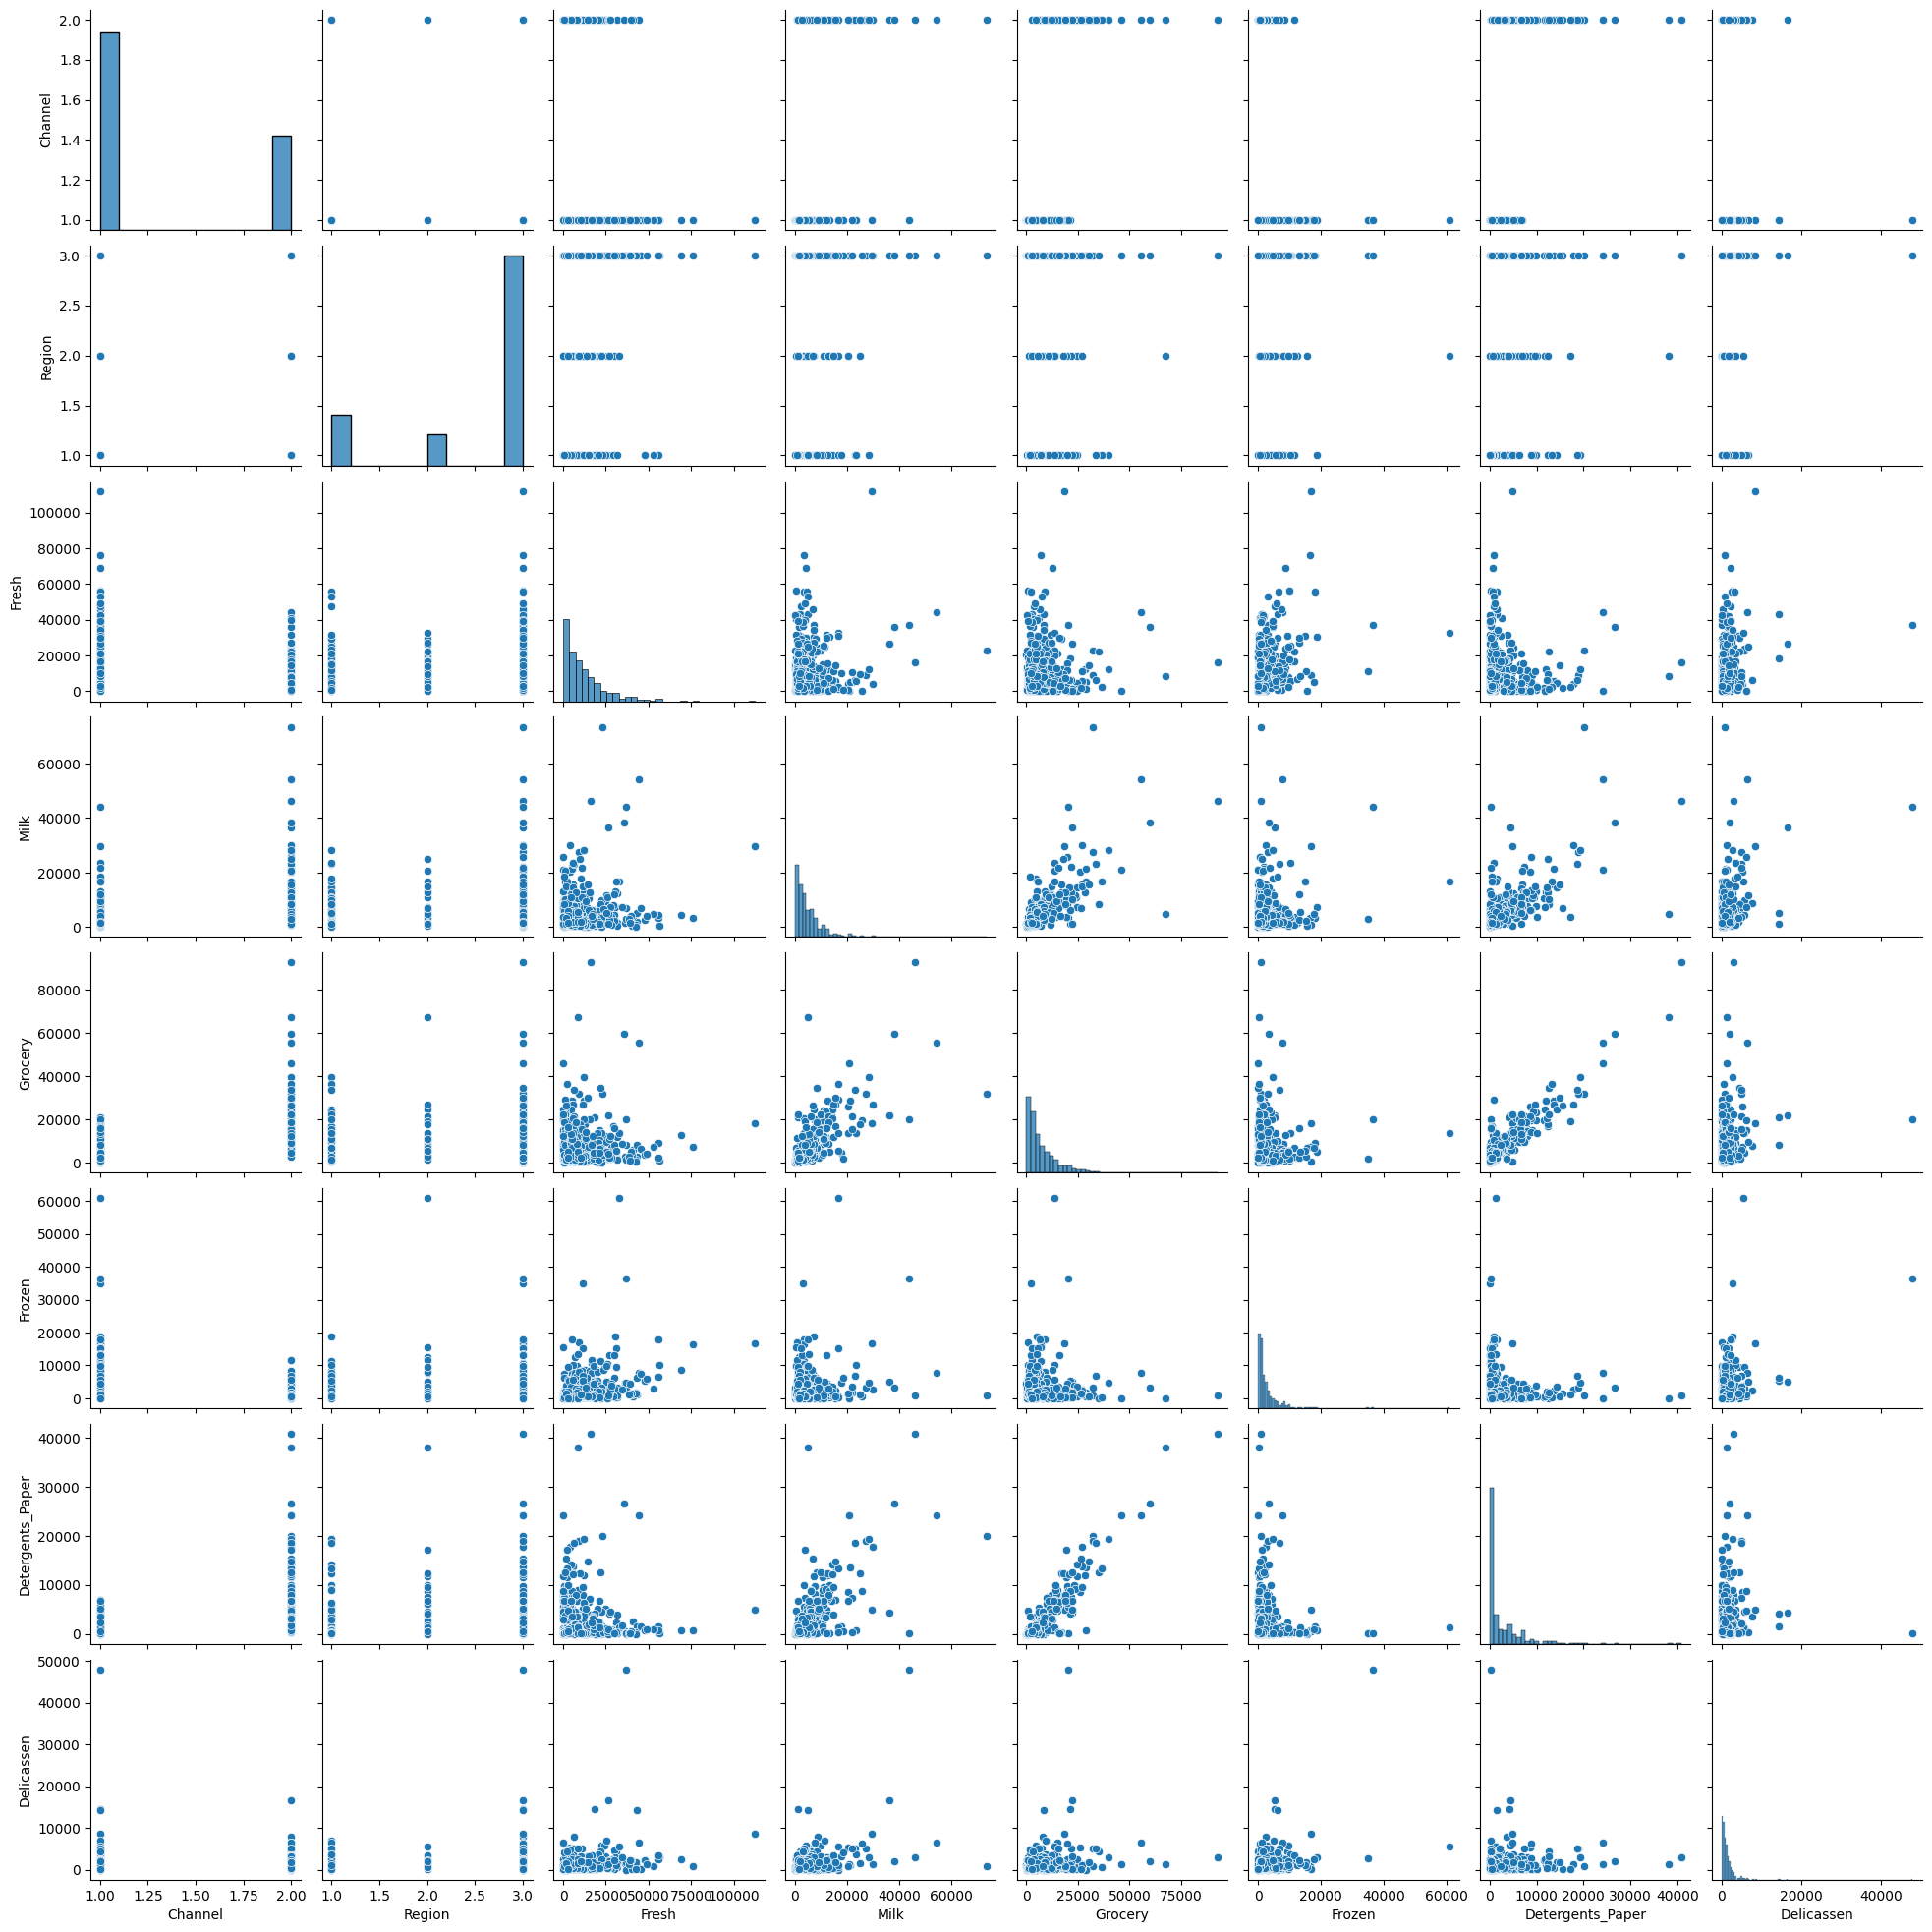

In [12]:
pair = sns.pairplot(

    df,

    diag_kind="hist"

)

pair.savefig(
    project_dir / "images" / "pairplot.png",
    dpi=300
)

plt.show()

## Boxplots (Outlier Detection)

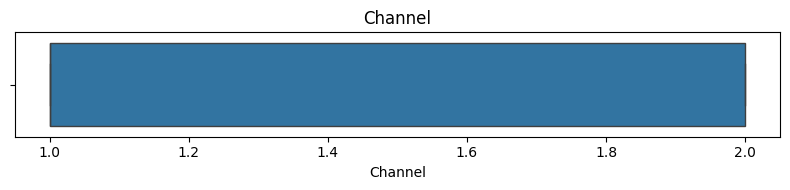

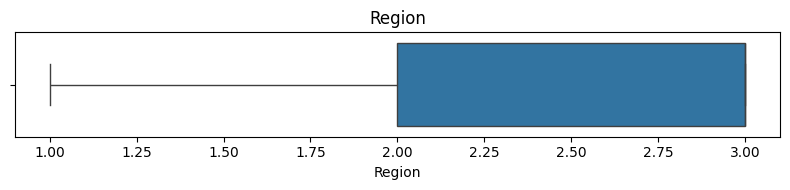

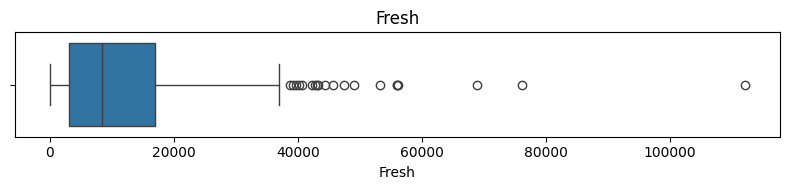

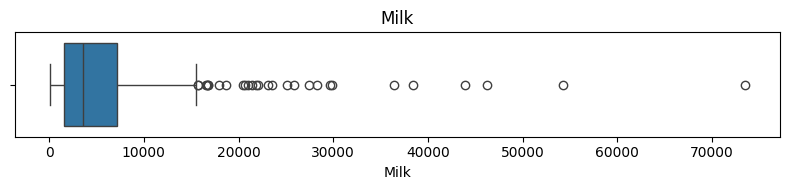

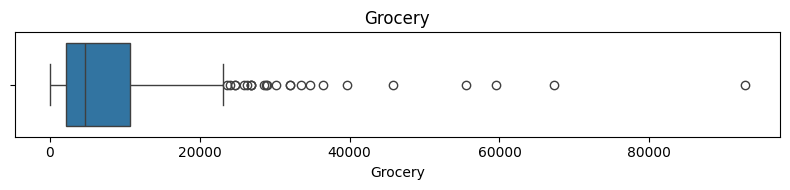

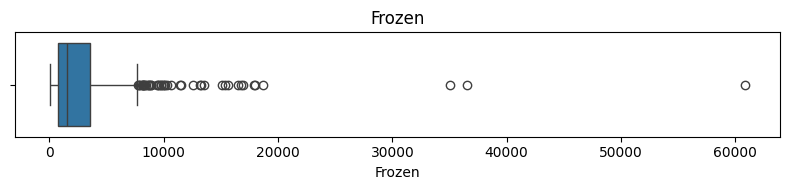

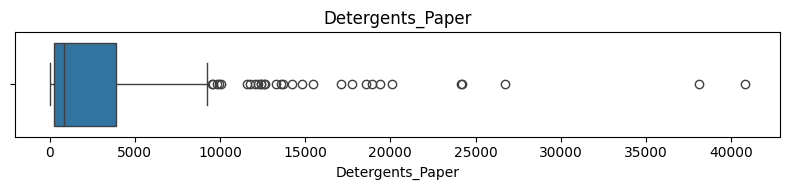

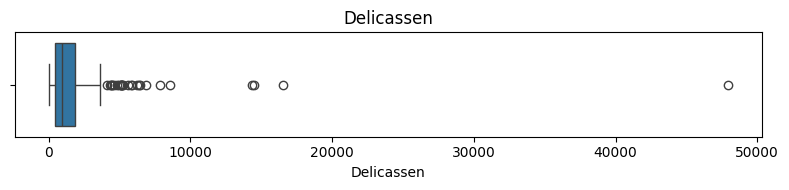

In [13]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:

    plt.figure(figsize=(8,2))

    sns.boxplot(

        x=df[column]

    )

    plt.title(column)

    plt.tight_layout()
  
   
    plt.show()

## Distribution Plots

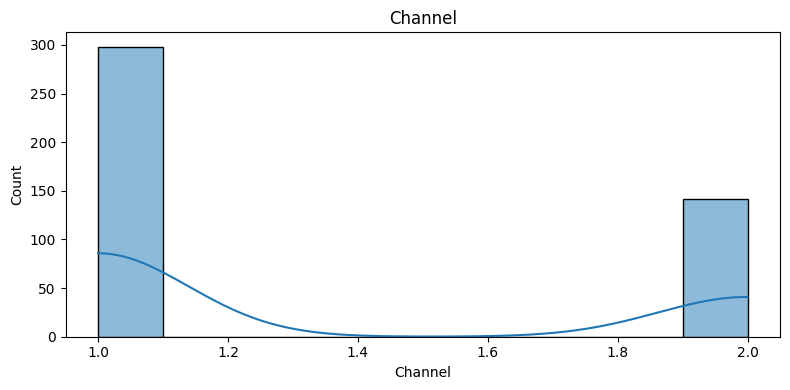

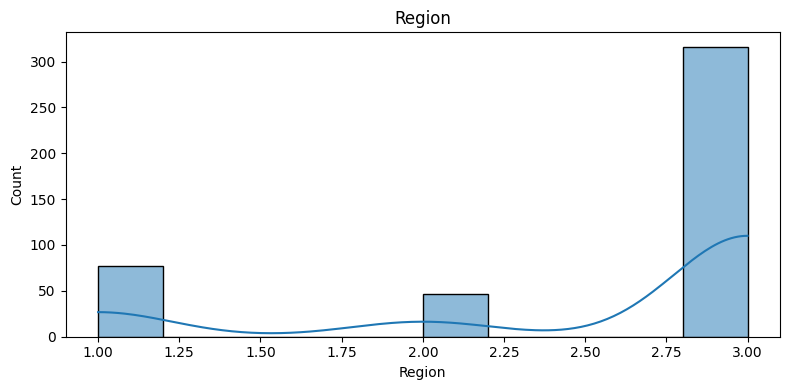

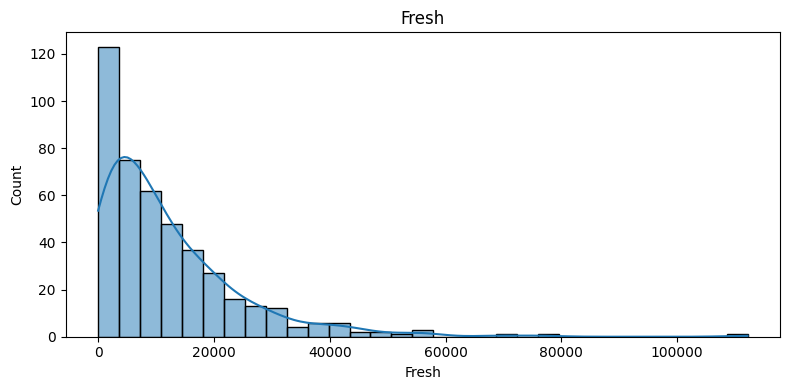

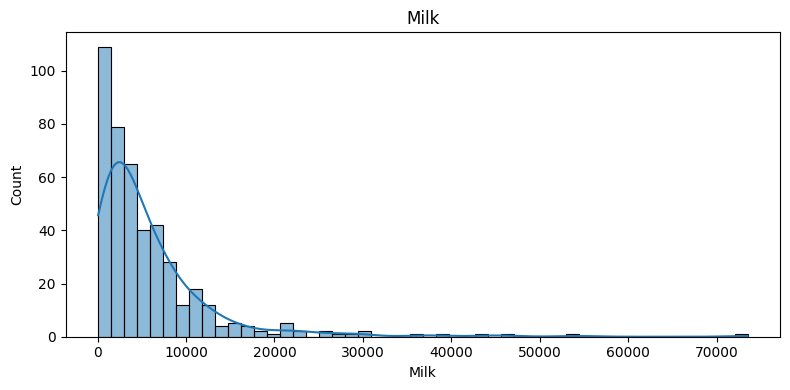

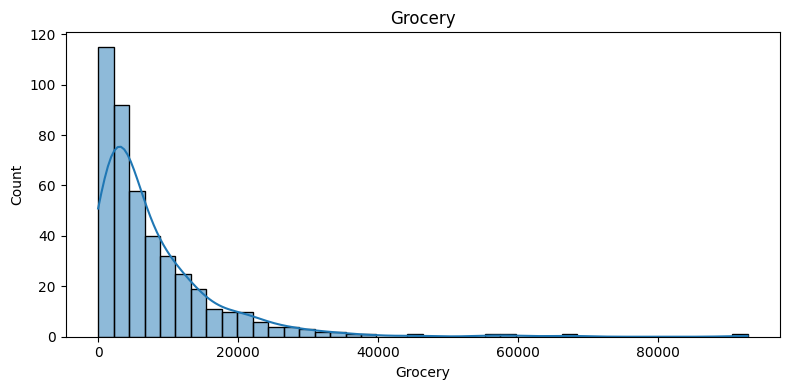

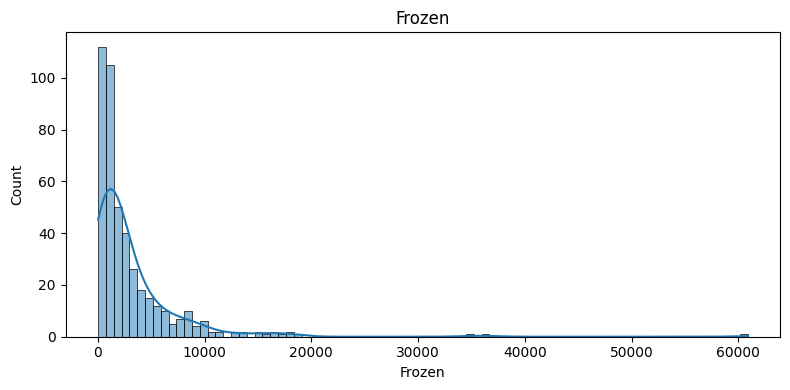

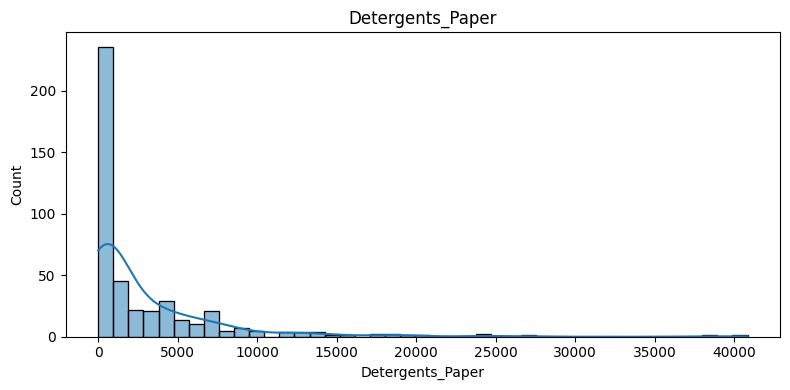

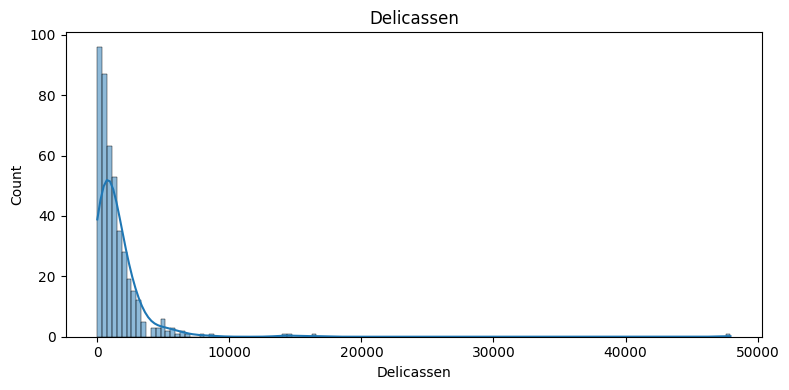

In [14]:
for column in df.columns:

    plt.figure(figsize=(8,4))

    sns.histplot(

        df[column],

        kde=True

    )

    plt.title(column)

    plt.tight_layout()

    plt.show()

## Feature Selection

We'll use all purchasing features for clustering. The Channel and Region columns are identifiers/categories and are excluded.

In [15]:
X = df[[
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]]

print(X.head())

   Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669  9656     7561     214              2674        1338
1   7057  9810     9568    1762              3293        1776
2   6353  8808     7684    2405              3516        7844
3  13265  1196     4221    6404               507        1788
4  22615  5410     7198    3915              1777        5185


## Standardize the Features
## Feature Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Data Shape:", X_scaled.shape)

Scaled Data Shape: (440, 6)


## Determine the Optimal Number of Clusters (Elbow Method)
Choose the value of K where the curve starts to flatten (often 3–5 for this dataset).

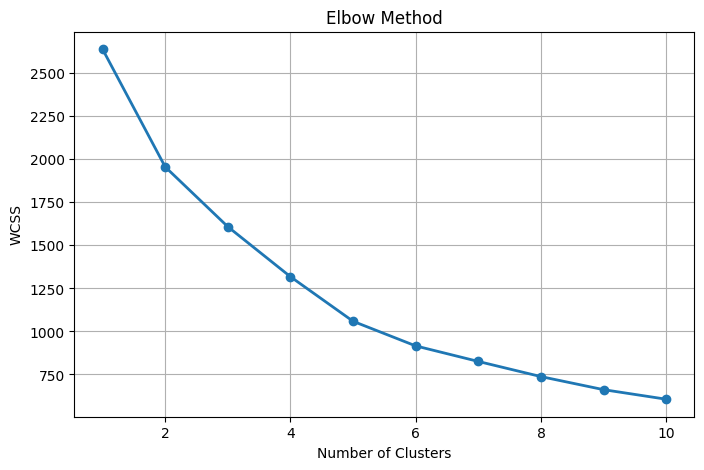

In [17]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o',
    linewidth=2
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.savefig(
    str(project_dir / "images" / "elbow_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Silhouette Score Analysis

The highest silhouette score generally indicates the best number of clusters.

   Clusters  Silhouette Score
0         2          0.547215
1         3          0.548287
2         4          0.348471
3         5          0.369040
4         6          0.378229
5         7          0.334282
6         8          0.320116
7         9          0.309028
8        10          0.311214


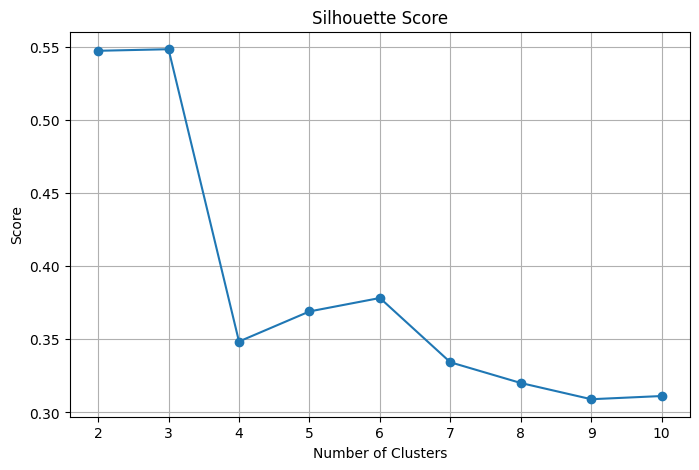

In [18]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

silhouette_df = pd.DataFrame({

    "Clusters":range(2,11),

    "Silhouette Score":scores

})

print(silhouette_df)

silhouette_df.to_csv(
    project_dir / "results" / "silhouette_scores.csv",
    index=False
)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker='o'
)

plt.title("Silhouette Score")

plt.xlabel("Number of Clusters")

plt.ylabel("Score")

plt.grid(True)

plt.savefig(
    str(project_dir / "images" / "silhouette_score.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Train the Final K-Means Model

Replace 3 with the best value found from the Elbow Method and Silhouette Score.

In [19]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print(df.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
2        2       3   6353  8808     7684    2405              3516   
3        1       3  13265  1196     4221    6404               507   
4        2       3  22615  5410     7198    3915              1777   

   Delicassen  Cluster  
0        1338        1  
1        1776        1  
2        7844        1  
3        1788        1  
4        5185        1  


## Cluster Distribution

Cluster
0     45
1    393
2      2
Name: count, dtype: int64


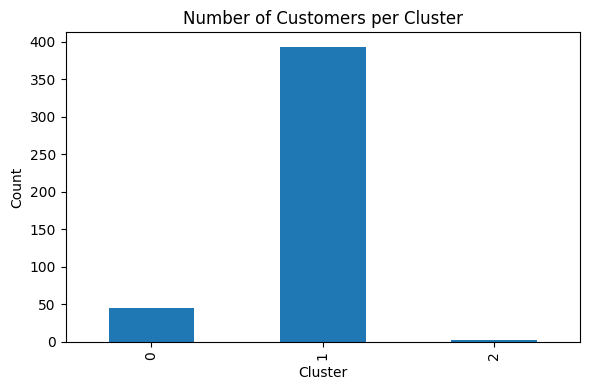

In [20]:
cluster_counts = df["Cluster"].value_counts().sort_index()

print(cluster_counts)

cluster_counts.to_csv(
    str(project_dir / "results" / "cluster_sizes.csv")
)

plt.figure(figsize=(6,4))

cluster_counts.plot(
    kind="bar"
)

plt.title("Number of Customers per Cluster")

plt.xlabel("Cluster")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    str(project_dir / "images" / "cluster_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## View Cluster Sizes

In [21]:
cluster_count = df["Cluster"].value_counts().sort_index()

print(cluster_count)

cluster_count.to_csv(
    project_dir / "results" / "cluster_sizes.csv"
)

Cluster
0     45
1    393
2      2
Name: count, dtype: int64


## Cluster Profiling
This table shows the average spending for each cluster across all product categories.

In [22]:
cluster_profile = df.groupby("Cluster").mean(numeric_only=True)

print(cluster_profile)

cluster_profile.to_csv(
    project_dir / "results" / "cluster_profile.csv"
)

          Channel    Region         Fresh          Milk       Grocery  \
Cluster                                                                 
0        1.977778  2.511111  10440.933333  19386.422222  28656.088889   
1        1.249364  2.547074  12062.913486   4115.099237   5534.966921   
2        1.000000  2.500000  34782.000000  30367.000000  16898.000000   

               Frozen  Detergents_Paper    Delicassen  
Cluster                                                
0         2190.244444      13327.800000   2374.200000  
1         2940.676845       1696.170483   1299.114504  
2        48701.500000        755.500000  26776.000000  


## Export Clustered Dataset

In [23]:
output_path = project_dir / "results" / "Wholesale_Customers_Clustered.csv"

df.to_csv(output_path, index=False)

print("Clustered dataset saved successfully.")

Clustered dataset saved successfully.


## Save the Trained K-Means Model

In [24]:
import joblib

joblib.dump(
    kmeans,
    project_dir / "models" / "kmeans_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


## PCA Visualization (2D)

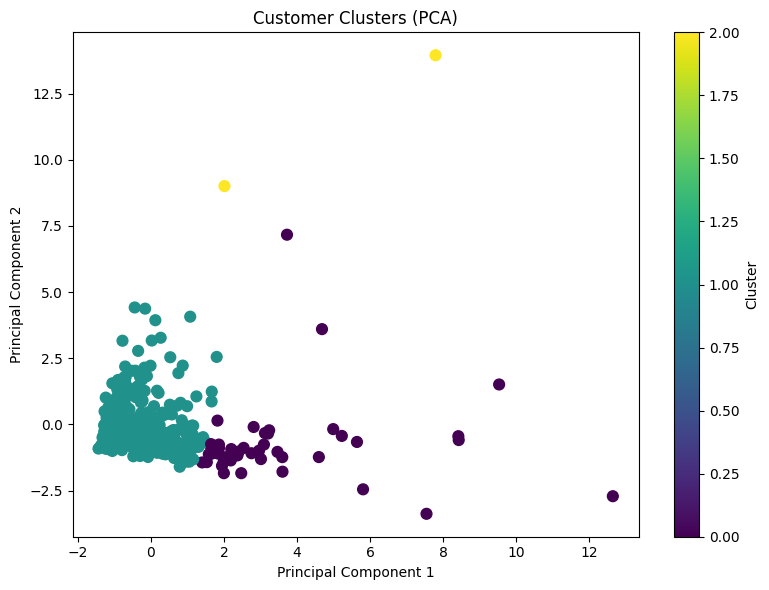

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(

    X_pca[:,0],

    X_pca[:,1],

    c=clusters,

    cmap="viridis",

    s=60

)

plt.title("Customer Clusters (PCA)")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.tight_layout()

plt.savefig(
    str(project_dir / "images" / "pca_clusters.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Hierarchical Clustering (Dendrogram)

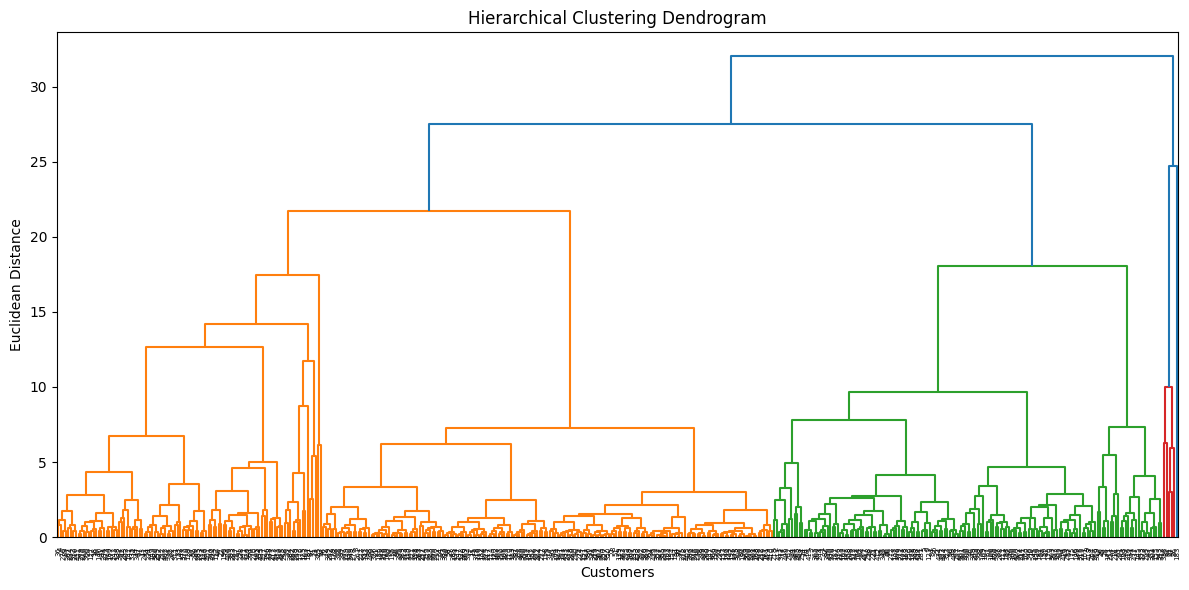

In [26]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12,6))

dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.tight_layout()

plt.savefig(
    str(project_dir / "images" / "hierarchical_dendrogram.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Agglomerative Hierarchical Clustering

In [27]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=5,
    metric="euclidean",
    linkage="ward"
)

hc_labels = hc.fit_predict(X_scaled)

df["Hierarchical Cluster"] = hc_labels

## Visualize Hierarchical Clusters

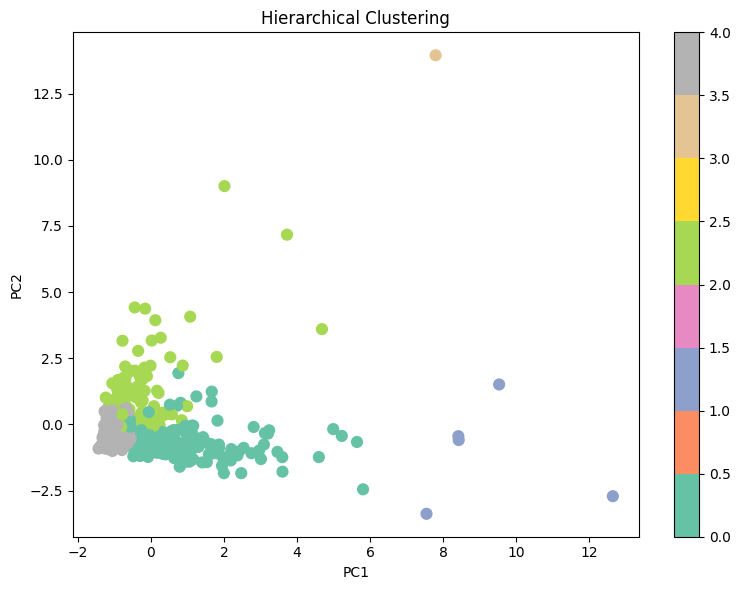

In [28]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(

    X_pca[:,0],

    X_pca[:,1],

    c=hc_labels,

    cmap="Set2",

    s=60

)

plt.title("Hierarchical Clustering")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.colorbar()

plt.tight_layout()

plt.savefig(
    str(project_dir / "images" / "hierarchical_clusters.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## DBSCAN Clustering

In [29]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(

    eps=1.5,

    min_samples=5

)

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN Cluster"] = db_labels

print(df["DBSCAN Cluster"].value_counts())

DBSCAN Cluster
 0    413
-1     27
Name: count, dtype: int64


## Visualize DBSCAN

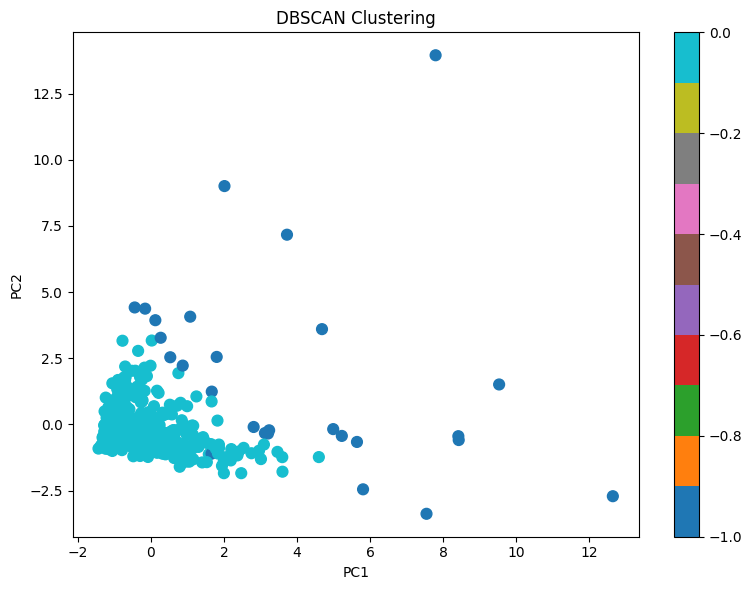

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(

    X_pca[:,0],

    X_pca[:,1],

    c=db_labels,

    cmap="tab10",

    s=60

)

plt.title("DBSCAN Clustering")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.colorbar()

plt.tight_layout()

plt.savefig(
    str(project_dir / "images" / "dbscan_clusters.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Compare Clustering Algorithms

In [31]:
comparison = pd.DataFrame({

    "KMeans":clusters,

    "Hierarchical":hc_labels,

    "DBSCAN":db_labels

})

print(comparison.head())

comparison.to_csv(
    project_dir / "results" / "clustering_comparison.csv",
    index=False
)

   KMeans  Hierarchical  DBSCAN
0       1             0       0
1       1             0       0
2       1             0       0
3       1             4       0
4       1             2       0


## Compare Silhouette Scores

In [32]:
from sklearn.metrics import silhouette_score

scores = {}

scores["KMeans"] = silhouette_score(

    X_scaled,

    clusters

)

scores["Hierarchical"] = silhouette_score(

    X_scaled,

    hc_labels

)

valid = db_labels != -1

if len(set(db_labels[valid])) > 1:

    scores["DBSCAN"] = silhouette_score(

        X_scaled[valid],

        db_labels[valid]

    )

else:

    scores["DBSCAN"] = np.nan

score_df = pd.DataFrame(

    scores.items(),

    columns=[

        "Algorithm",

        "Silhouette Score"

    ]

)

print(score_df)

score_df.to_csv(

    project_dir / "results" / "algorithm_comparison.csv",

    index=False
)

      Algorithm  Silhouette Score
0        KMeans          0.548287
1  Hierarchical          0.239884
2        DBSCAN               NaN


## Bar Chart Comparison

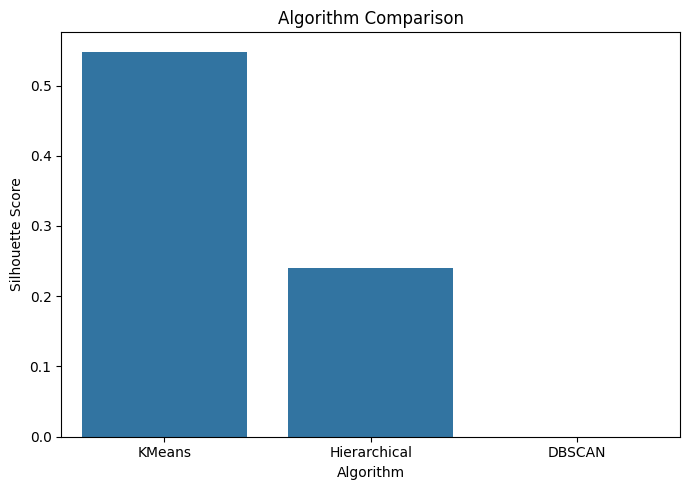

In [33]:
plt.figure(figsize=(7,5))

sns.barplot(

    data=score_df,

    x="Algorithm",

    y="Silhouette Score"

)

plt.title("Algorithm Comparison")

plt.tight_layout()

plt.show()

## Cluster Profile Visualization

In [34]:
cluster_profile = df.groupby(

    "Cluster"

)[

    [

        "Fresh",

        "Milk",

        "Grocery",

        "Frozen",

        "Detergents_Paper",

        "Delicassen"

    ]

].mean()

print(cluster_profile)

cluster_profile.to_csv(
    project_dir / "results" / "cluster_profile.csv"
)

                Fresh          Milk       Grocery        Frozen  \
Cluster                                                           
0        10440.933333  19386.422222  28656.088889   2190.244444   
1        12062.913486   4115.099237   5534.966921   2940.676845   
2        34782.000000  30367.000000  16898.000000  48701.500000   

         Detergents_Paper    Delicassen  
Cluster                                  
0            13327.800000   2374.200000  
1             1696.170483   1299.114504  
2              755.500000  26776.000000  


## Cluster Profile Heatmap

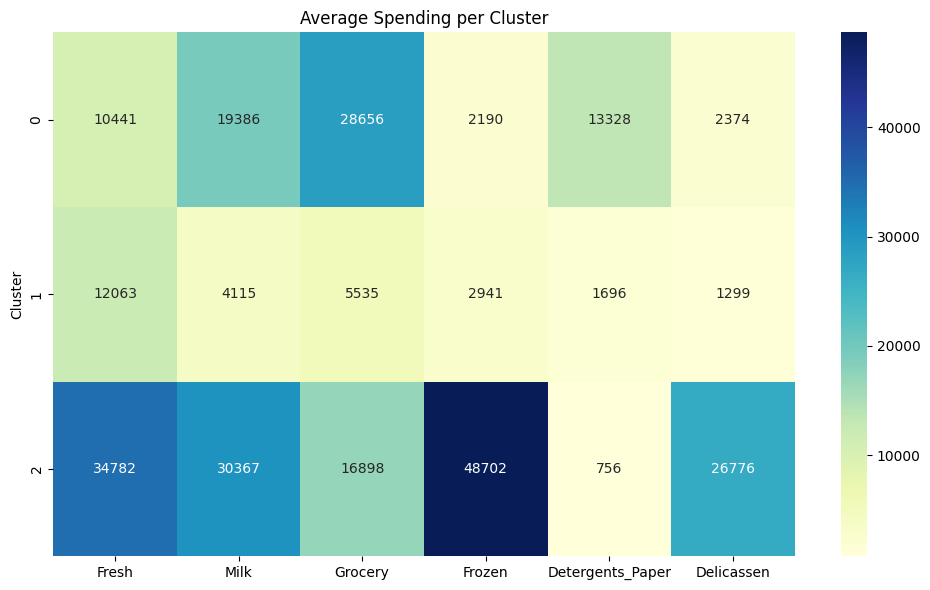

In [35]:
plt.figure(figsize=(10,6))

sns.heatmap(

    cluster_profile,

    annot=True,

    cmap="YlGnBu",

    fmt=".0f"

)

plt.title("Average Spending per Cluster")

plt.tight_layout()

plt.savefig(
    str(project_dir / "images" / "cluster_profile_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Save All Results

In [36]:
from pathlib import Path
import joblib

project_path = Path.cwd()

models_path = project_path / "models"

models_path.mkdir(exist_ok=True)

joblib.dump(
    scaler,
    models_path / "scaler.pkl"
)

joblib.dump(
    kmeans,
    models_path / "kmeans_model.pkl"
)

print("Models saved successfully!")

Models saved successfully!


## Generate a PDF Report

## Business Interpretation

After reviewing the cluster profile, you can describe each segment. For example:

Cluster	Interpretation
Cluster 0	Customers with high spending across most product categories (high-value customers).
Cluster 1	Customers with moderate and balanced purchasing behavior.
Cluster 2	Customers with lower spending, representing occasional or low-volume buyers.